# Day 1: Data Curation — Vietnamese Price Prediction Dataset

Pipeline: Load 121K products from Tiki JSONL -> Clean (9-step Vietnamese pipeline) -> Dedup -> EDA -> Weighted Sampling -> Split -> Push to HuggingFace Hub

**Dataset:** 54 JSONL files (48 Tiki scraper + 6 Kaggle)
**Target:** ~110K items, split 100K/5K/5K (train/val/test)
**HuggingFace:** SeanSunny/items_raw_tv

In [1]:
import json
import random
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

from pricer_vi.items import Item
from pricer_vi.parser import parse

In [2]:
# Configuration
DATA_DIR = Path("../Tiki/Tiki_dataset_scrape")
RANDOM_SEED = 42
HF_DATASET_NAME = "SeanSunny/items_raw_tv"
TRAIN_SIZE = 100_000
VAL_SIZE = 5_000
TEST_SIZE = 5_000

## Step 1: Load all JSONL files

In [3]:
items = []
for filepath in sorted(DATA_DIR.glob("*.jsonl")):
    is_kaggle = "kaggle" in filepath.name
    count = 0
    for line in open(filepath, encoding="utf-8"):
        datapoint = json.loads(line)
        if is_kaggle:
            category = "Th\u1eddi Trang"
        else:
            raw_cat = datapoint.get("category", "")
            category = raw_cat.split(" > ")[0] if " > " in raw_cat else raw_cat
        item = parse(datapoint, category)
        if item:
            items.append(item)
            count += 1
    print(f"  {filepath.name}: {count:,} items")

print(f"\nTotal loaded: {len(items):,} items")

  tiki_11601.jsonl: 1,169 items
  tiki_12884.jsonl: 1,947 items
  tiki_15074.jsonl: 1,304 items
  tiki_1582.jsonl: 2,380 items
  tiki_1591.jsonl: 597 items
  tiki_1592.jsonl: 579 items
  tiki_1594.jsonl: 707 items
  tiki_1595.jsonl: 435 items
  tiki_1884.jsonl: 2,088 items
  tiki_1946.jsonl: 2,559 items
  tiki_1951.jsonl: 3,199 items
  tiki_1954.jsonl: 1,805 items
  tiki_1966.jsonl: 3,222 items
  tiki_1973.jsonl: 2,363 items
  tiki_1974.jsonl: 4,631 items
  tiki_2015.jsonl: 3,102 items
  tiki_2150.jsonl: 4,631 items
  tiki_2223.jsonl: 2,706 items
  tiki_22998.jsonl: 1,411 items
  tiki_2306.jsonl: 1,020 items
  tiki_2328.jsonl: 225 items
  tiki_24832.jsonl: 2,258 items
  tiki_26568.jsonl: 198 items
  tiki_2663.jsonl: 835 items
  tiki_27550.jsonl: 1,720 items
  tiki_28432.jsonl: 471 items
  tiki_28670.jsonl: 2,666 items
  tiki_3862.jsonl: 167 items
  tiki_3864.jsonl: 87 items
  tiki_3865.jsonl: 159 items
  tiki_3866.jsonl: 145 items
  tiki_4421.jsonl: 80 items
  tiki_4422.jsonl: 702 item

In [4]:
# Inspect a sample item
items[0]

<Ghế Ngồi Ô Tô Cho Bé, ️FREESHIP️ Ghế ngồi xe hơi cho bé, ghế giữ bé an toàn trên ô tô, Đai An Toàn Trên Xe Hơi Cho Bé = 185,000 VND>

In [5]:
print(items[0].full[:500])

Ghế Ngồi Ô Tô Cho Bé, FREESHIP Ghế ngồi xe hơi cho bé, ghế giữ bé an toàn trên ô tô, Đai An Toàn Trên Xe Hơi Cho Bé
Ghế ngồi oto cho bé , ghế giữ bé trên ô tô , ghế ngồi ô tô Size dưới 30kgDành cho các mẹ hay người lớn muốn đảm bảo an toàn cho bé khi lái xe.Khi đi ô tô bé cần được người lớn chú ý bảo vệ bé để bé ... | Ghế ngồi oto cho bé , ghế giữ bé trên ô tô , ghế ngồi ô tô Size dưới 30kg Dành cho các mẹ hay người lớn muốn đảm bảo an toàn cho bé khi lái xe. Khi đi ô tô bé cần được người lớn ch


## Step 2: EDA (before dedup)

In [6]:
lengths = [len(item.full) for item in items]
prices = [item.price for item in items]

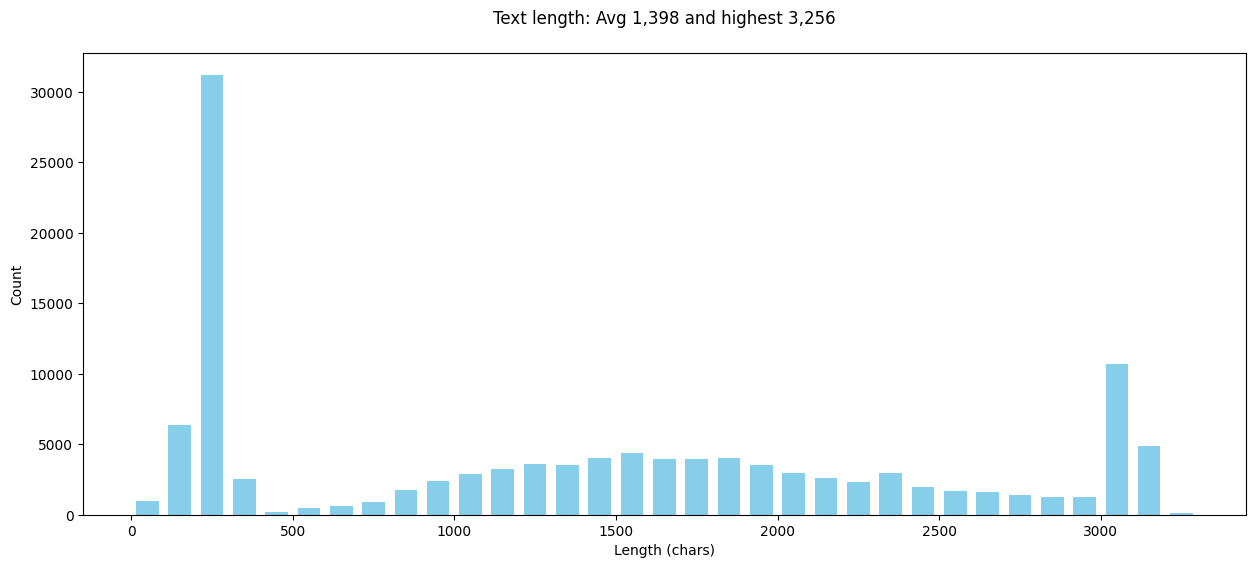

In [7]:
# Text length distribution
plt.figure(figsize=(15, 6))
plt.title(f"Text length: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
plt.xlabel("Length (chars)")
plt.ylabel("Count")
plt.hist(lengths, rwidth=0.7, color="skyblue", bins=range(0, min(max(lengths)+100, 6000), 100))
plt.show()

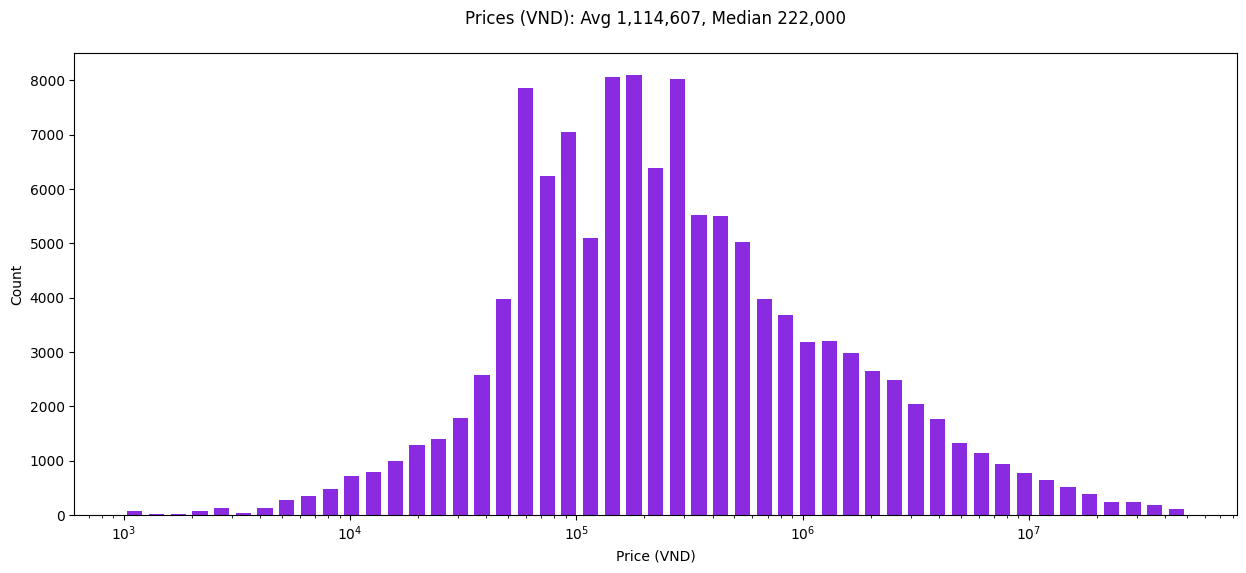

In [8]:
# Price distribution (log scale for VND)
plt.figure(figsize=(15, 6))
plt.title(f"Prices (VND): Avg {sum(prices)/len(prices):,.0f}, Median {int(np.median(prices)):,}\n")
plt.xlabel("Price (VND)")
plt.ylabel("Count")
log_bins = np.logspace(np.log10(max(min(prices), 1)), np.log10(max(prices) + 1), 50)
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=log_bins)
plt.xscale("log")
plt.show()

## Step 3: Deduplication

In [9]:
random.seed(RANDOM_SEED)
random.shuffle(items)

seen = set()
items = [x for x in tqdm(items) if not (x.title in seen or seen.add(x.title))]

seen = set()
items = [x for x in tqdm(items) if not (x.full in seen or seen.add(x.full))]

del seen
print(f"After deduplication: {len(items):,} items")

  0%|          | 0/120528 [00:00<?, ?it/s]

  0%|          | 0/114994 [00:00<?, ?it/s]

After deduplication: 114,778 items


## Step 4: EDA (after dedup)

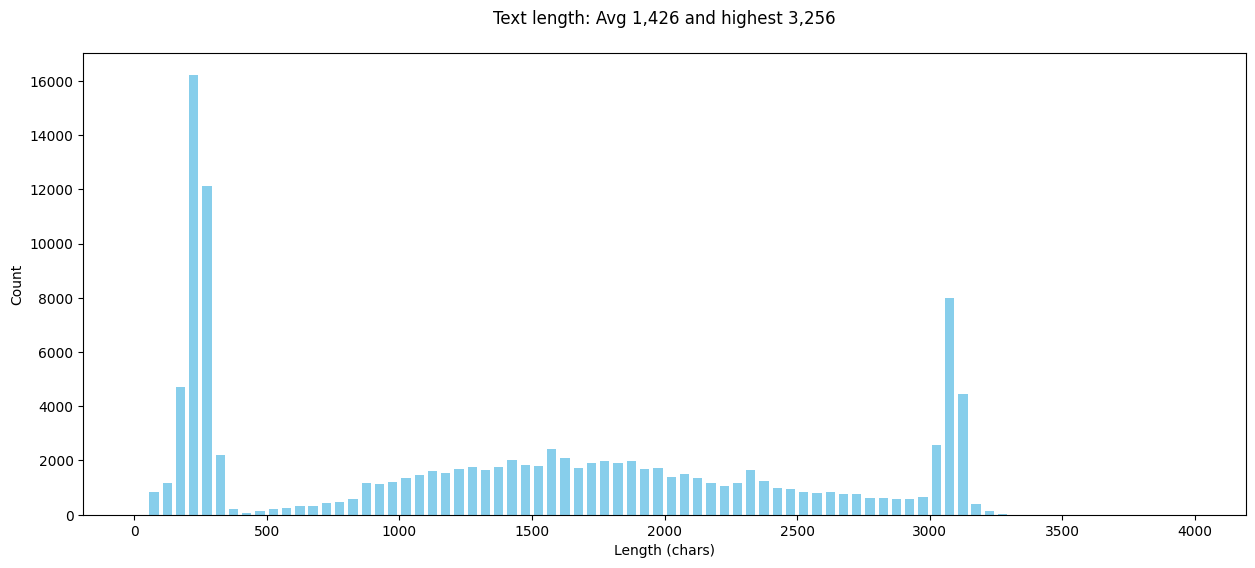

In [10]:
lengths = [len(item.full) for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Text length: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
plt.xlabel("Length (chars)")
plt.ylabel("Count")
plt.hist(lengths, rwidth=0.7, color="skyblue", bins=range(0, 4050, 50))
plt.show()

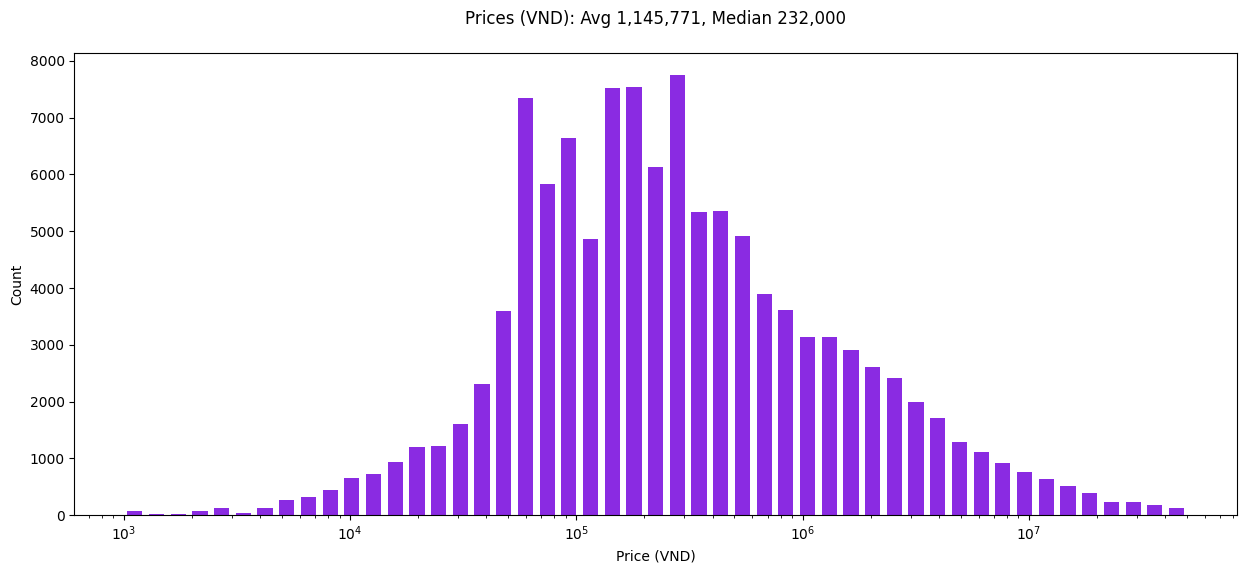

In [11]:
prices = [item.price for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Prices (VND): Avg {sum(prices)/len(prices):,.0f}, Median {int(np.median(prices)):,}\n")
plt.xlabel("Price (VND)")
plt.ylabel("Count")
log_bins = np.logspace(np.log10(max(min(prices), 1)), np.log10(max(prices) + 1), 50)
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=log_bins)
plt.xscale("log")
plt.show()

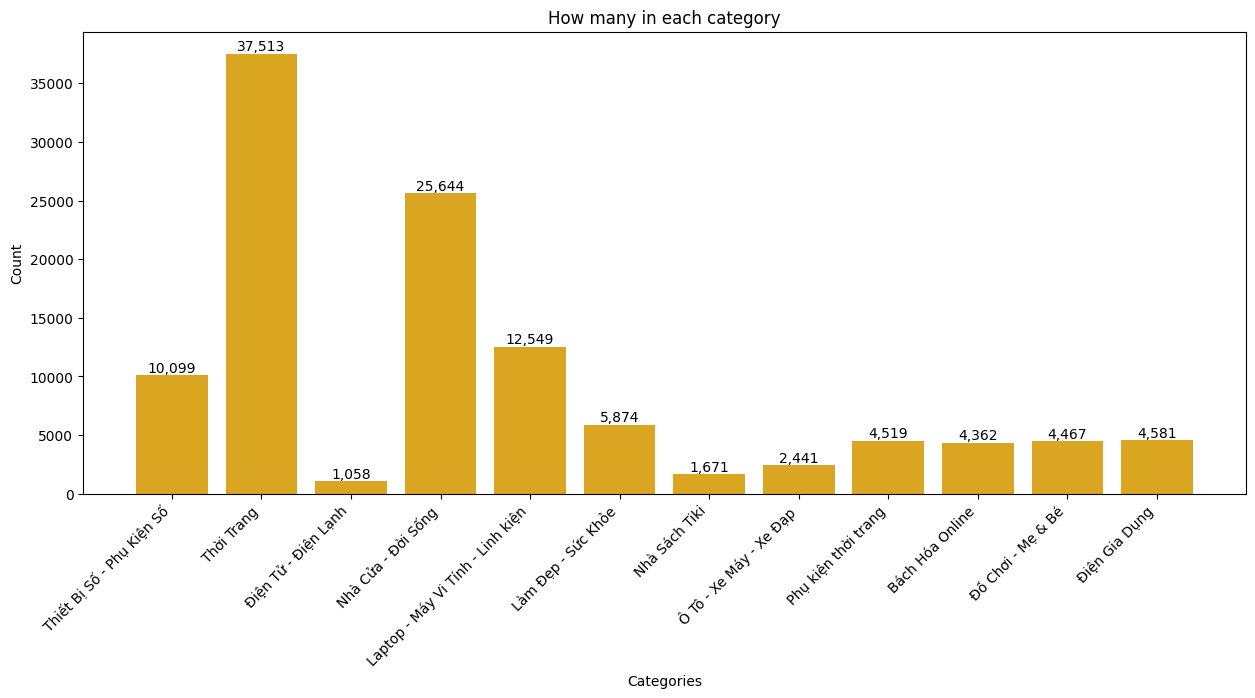

In [12]:
# Category distribution
category_counts = Counter([item.category for item in items])
categories = list(category_counts.keys())
counts = [category_counts[c] for c in categories]

plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title("How many in each category")
plt.xlabel("Categories")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.show()

## Step 5: Weighted Sampling

In [13]:
np.random.seed(RANDOM_SEED)

target_size = TRAIN_SIZE + VAL_SIZE + TEST_SIZE
sample_size = min(len(items), target_size)

prices_arr = np.array([it.price for it in items], dtype=float)
categories_arr = np.array([it.category for it in items])

# Normalize prices to [0, 1]
p = (prices_arr - prices_arr.min()) / (prices_arr.max() - prices_arr.min() + 1e-9)

# Price^2 weighting
w = p ** 2

# Category penalties (uncomment after reviewing EDA)
# w[categories_arr == "Th\u1eddi Trang"] *= 0.3

# Normalize
w = w / w.sum()

idx = np.random.choice(len(items), size=sample_size, replace=False, p=w)
sample = [items[i] for i in idx]
print(f"Sample size: {len(sample):,}")

Sample size: 110,000


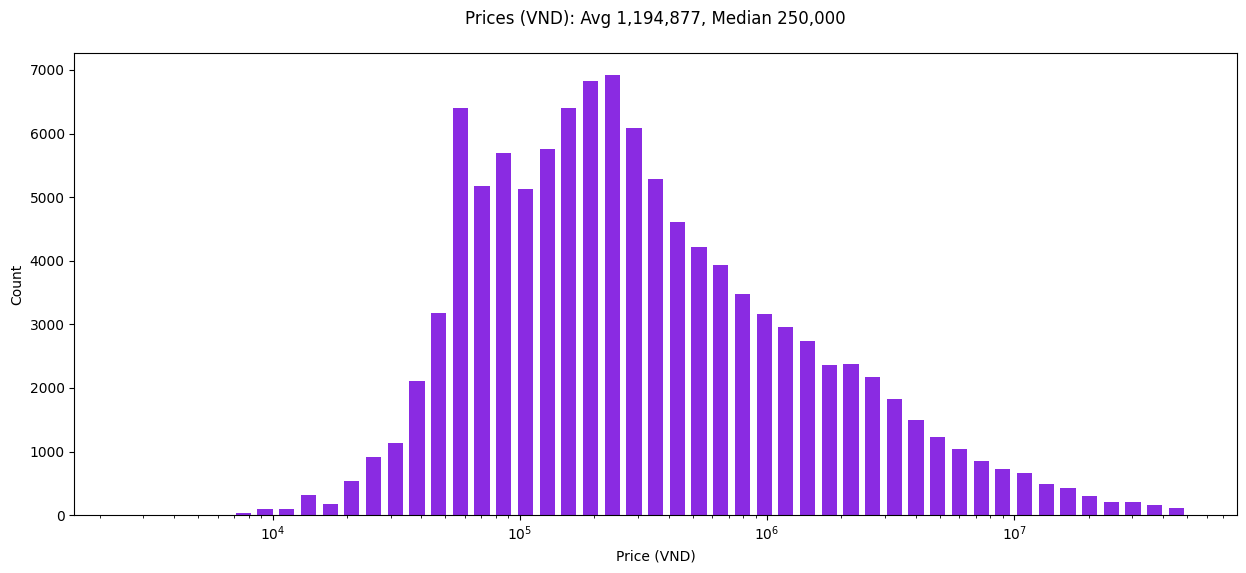

In [14]:
# Price distribution after sampling
prices = [item.price for item in sample]
plt.figure(figsize=(15, 6))
plt.title(f"Prices (VND): Avg {sum(prices)/len(prices):,.0f}, Median {int(np.median(prices)):,}\n")
plt.xlabel("Price (VND)")
plt.ylabel("Count")
log_bins = np.logspace(np.log10(max(min(prices), 1)), np.log10(max(prices) + 1), 50)
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=log_bins)
plt.xscale("log")
plt.show()

In [15]:
# Final shuffle
random.seed(RANDOM_SEED)
random.shuffle(sample)

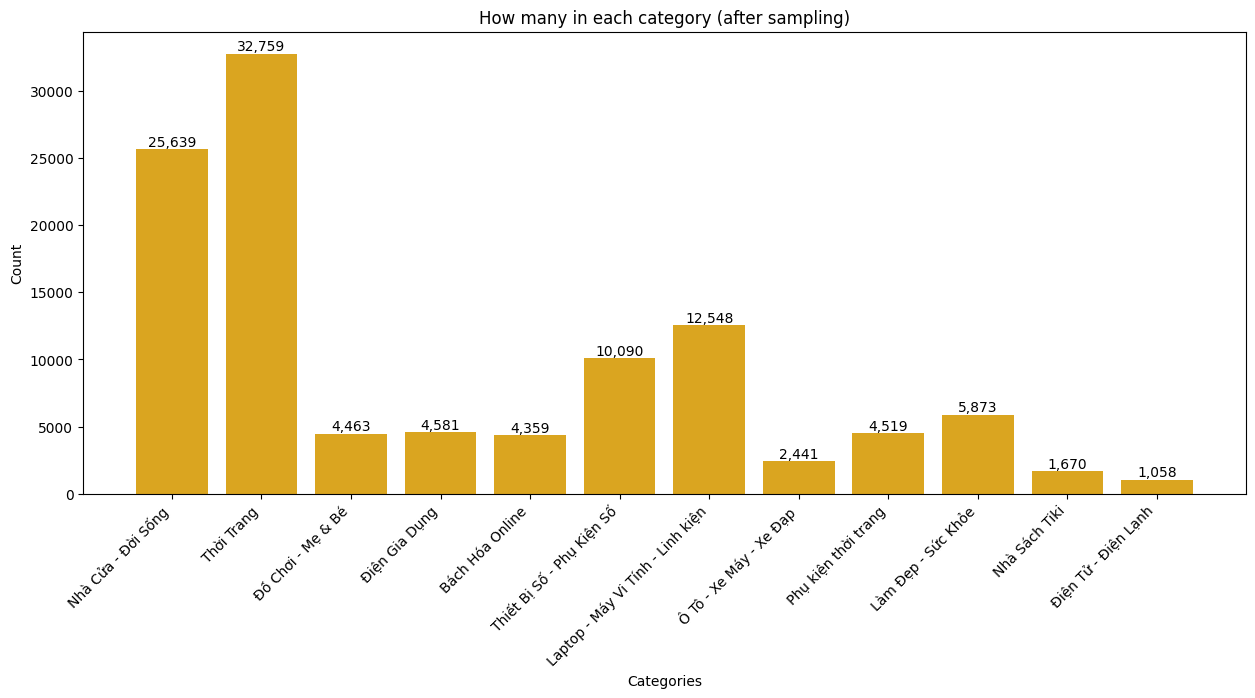

In [16]:
# Category distribution after sampling
category_counts = Counter([item.category for item in sample])
categories = list(category_counts.keys())
counts = [category_counts[c] for c in categories]

plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title("How many in each category (after sampling)")
plt.xlabel("Categories")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.show()

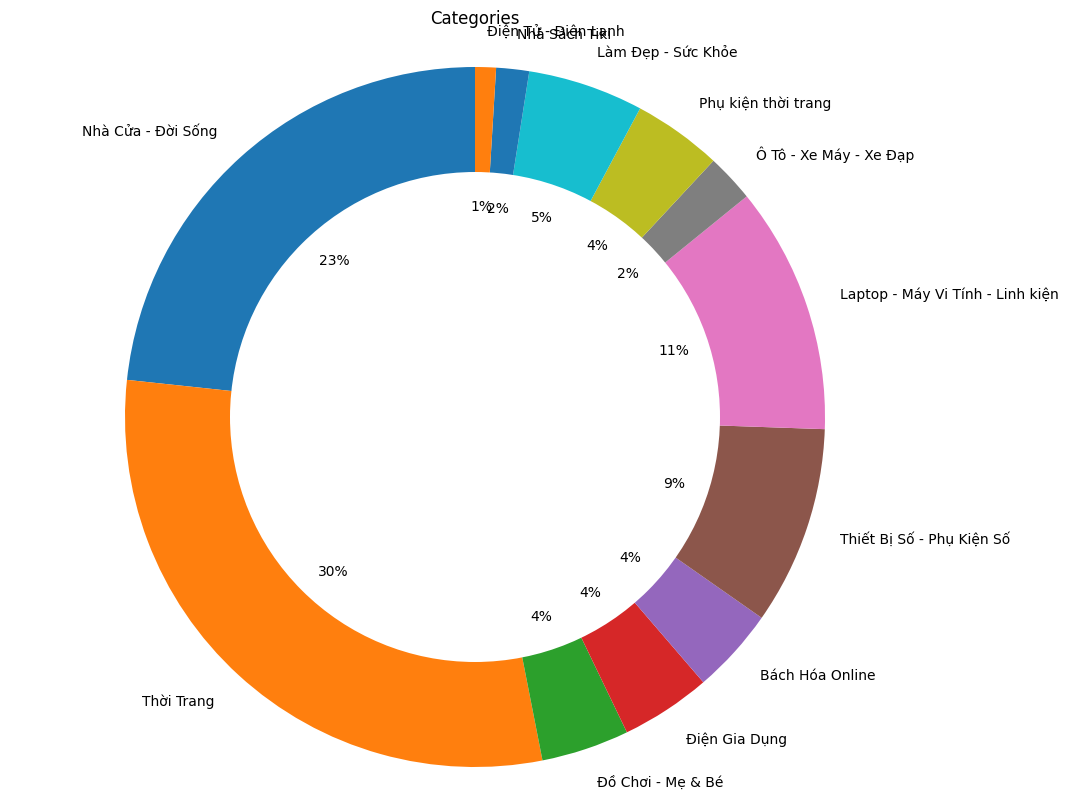

In [17]:
# Category pie chart
plt.figure(figsize=(12, 10))
plt.pie(counts, labels=categories, autopct="%1.0f%%", startangle=90)
centre_circle = plt.Circle((0, 0), 0.70, fc="white")
plt.gcf().gca().add_artist(centre_circle)
plt.title("Categories")
plt.axis("equal")
plt.show()

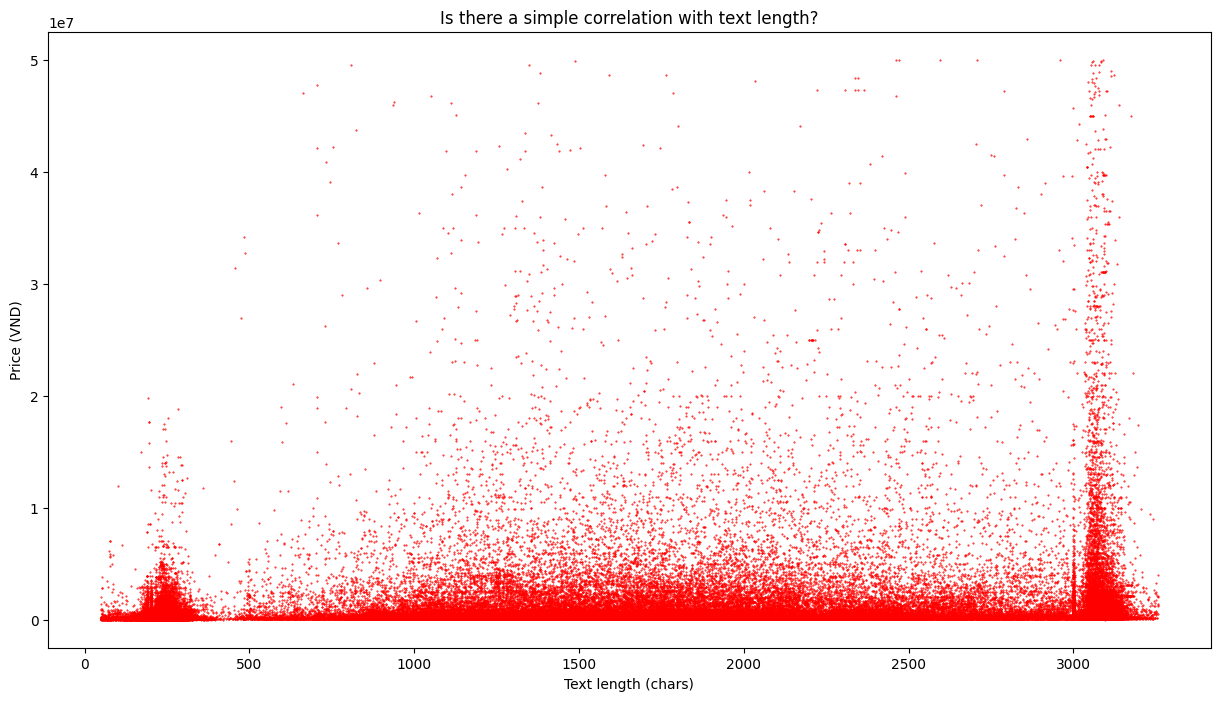

In [18]:
# Price vs text length scatter
sizes = [len(item.full) for item in sample]
prices = [item.price for item in sample]

plt.figure(figsize=(15, 8))
plt.scatter(sizes, prices, s=0.2, color="red")
plt.xlabel("Text length (chars)")
plt.ylabel("Price (VND)")
plt.title("Is there a simple correlation with text length?")
plt.show()

## Step 6: Split and Push to HuggingFace Hub

In [19]:
test = sample[:TEST_SIZE]
val = sample[TEST_SIZE:TEST_SIZE + VAL_SIZE]
train = sample[TEST_SIZE + VAL_SIZE:]
print(f"Train: {len(train):,}, Val: {len(val):,}, Test: {len(test):,}")

Train: 100,000, Val: 5,000, Test: 5,000


In [21]:
# Login to HuggingFace
from huggingface_hub import login
from dotenv import load_dotenv
import os

load_dotenv(override=True)
hf_token = os.environ.get("HF_TOKEN")
if hf_token:
    login(hf_token, add_to_git_credential=False)
else:
    print("Set HF_TOKEN in .env or login manually: login('your_token')")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [22]:
Item.push_to_hub(HF_DATASET_NAME, train, val, test)
print(f"Pushed to {HF_DATASET_NAME}")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/100 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md:   0%|          | 0.00/739 [00:00<?, ?B/s]

Pushed to SeanSunny/items_raw_tv
